# Baseline del proyecto MIA

Este notebook implementa el primer pipeline funcional del proyecto MIA para la clasificación inicial de tickets de una mesa de ayuda TI universitaria.

El flujo desarrollado corresponde al baseline solicitado para la Semana 4:

**Cargar datos → EDA básico → Limpiar texto → Vectorizar con TF-IDF → Entrenar Logistic Regression → Evaluar con Classification Report y matriz de confusión.**

## 1. Configuración inicial

En esta sección se cargan las librerías necesarias, se define la semilla aleatoria y se configuran las rutas de trabajo en Google Drive.

In [19]:
# Librerías estándar
import os
import re
import string
import warnings

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Configuración general
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Configuración inicial completada.")

✅ Configuración inicial completada.


## 2. Carga del dataset

En esta sección se conecta Google Drive y se carga el archivo original de tickets ubicado en la carpeta `01_data/raw`.

In [20]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ruta principal del proyecto
PROJECT_ROOT = "/content/drive/MyDrive/Proyecto_MIA"

# Ruta del dataset original
DATASET_PATH = f"{PROJECT_ROOT}/01_data/raw/tickets_raw_corte_01_2026-02-25.xlsx"

# Cargar dataset
df = pd.read_excel(DATASET_PATH)

print(f"Dataset cargado correctamente.")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente.
Registros: 24,392
Columnas : 42


## 3. EDA básico

En esta sección se realiza una revisión inicial del dataset para validar su estructura, identificar valores nulos y revisar la distribución de la variable objetivo `Grupo`.

In [21]:
# Dimensiones del dataset

print(f"Número de registros : {df.shape[0]:,}")
print(f"Número de columnas  : {df.shape[1]}")

display(df.head())

Número de registros : 24,392
Número de columnas  : 42


,Fecha de registro,Código,Título,Estado,Fecha firma cierre,Acción a realizar,Fecha firma solución,Firma solución,Escalado,Tipo,...,SLA,Solución para el usuario,Técnico que realiza última comunicación a cliente,Tiempo 1ª respuesta,Tiempo atención (horas / minutos),Tiempo de atención,Tiempo de cierre,Tiempo de cierre (horas / minutos),Tiempo de resolución,Última comunicación a cliente
0,2023-02-08 17:33:06,REQ 2023-003487,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:12,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5815.517578,0h 00m,0.00,5887.534241,5887h 32m,5815.517578,NaT
1,2023-02-09 10:00:07,REQ 2023-003539,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:12,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5813.517187,1h 24m,1.40,5885.533850,5885h 32m,5813.517187,NaT
2,2023-02-14 12:57:06,REQ 2023-003967,FORMULARIO 107,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:11,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5783.567188,5h 27m,5.45,5855.583851,5855h 35m,5783.567188,NaT
3,2023-02-20 17:45:06,REQ 2023-004390,Formulario 107,Cerrada,2025-09-11 09:32:54,Escalar a 2ª línea,2025-09-01 09:31:11,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5743.500000,3h 00m,3.00,5815.516663,5815h 31m,5743.500000,NaT
4,2023-02-22 11:18:06,REQ 2023-004477,Problemas en el servidor,Cerrada,2025-09-11 09:32:54,Escalar a 2ª línea,2025-09-01 09:31:10,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5731.217318,0h 08m,0.13,5803.233980,5803h 14m,5731.217318,NaT


In [22]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24392 entries, 0 to 24391
Data columns (total 42 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   Fecha de registro                                  24392 non-null  datetime64[ns]
 1   Código                                             24392 non-null  object        
 2   Título                                             24392 non-null  object        
 3   Estado                                             24392 non-null  object        
 4   Fecha firma cierre                                 14364 non-null  datetime64[ns]
 5   Acción a realizar                                  24392 non-null  object        
 6   Fecha firma solución                               16849 non-null  datetime64[ns]
 7   Firma solución                                     16849 non-null  object        
 8   Escalado        

### Análisis preliminar del conjunto de datos

La inspección inicial muestra que el dataset está compuesto por **24.392 tickets** y **42 variables** de diferentes tipos (texto, fechas y variables numéricas).

De acuerdo con el objetivo del proyecto y con las validaciones realizadas con el personal de la mesa de ayuda, el modelo baseline utilizará como variable objetivo el campo **Grupo**, ya que representa la asignación inicial del grupo resolutorio en la mayoría de los casos.

Asimismo, para evitar *Data Leakage*, en esta primera versión no se utilizarán variables que contienen información generada después de la clasificación inicial del ticket, como tiempos de resolución, tiempos de cierre, solución aplicada o información completada posteriormente durante el proceso de atención.

In [23]:
# Distribución de tickets por estado

estado_counts = (
    df["Estado"]
    .value_counts(dropna=False)
    .reset_index()
)

estado_counts.columns = ["Estado", "Cantidad"]

display(estado_counts)

print(f"\nNúmero de estados encontrados: {df['Estado'].nunique()}")

,Estado,Cantidad
0,Cerrada,18855
1,Rechazada,4687
2,Resuelta,445
3,Asignada a un grupo,388
4,Nueva,17



Número de estados encontrados: 5


### Selección de los tickets para el entrenamiento

El análisis de la variable **Estado** muestra que la mayoría de los tickets corresponden a los estados **Cerrada** y **Rechazada**.

De acuerdo con la validación realizada con el personal de la Dirección de Tecnologías, estos estados representan casos con una resolución definitiva. En cambio, los tickets en estado **Resuelta** pueden volver a abrirse si el usuario no está conforme con la solución, mientras que los estados **Nueva** y **Asignada a un grupo** corresponden a casos que aún se encuentran en proceso.

Por este motivo, el modelo baseline será entrenado únicamente con tickets en estado **Cerrada** y **Rechazada**, garantizando que el conjunto de entrenamiento represente decisiones operativas consolidadas y evitando incorporar registros cuyo flujo aún no ha finalizado.

In [24]:
# Valores nulos en las variables relevantes del proyecto

columnas_interes = ["Título", "Descripción", "Grupo"]

nulos = (
    df[columnas_interes]
    .isnull()
    .sum()
    .reset_index()
)

nulos.columns = ["Variable", "Valores nulos"]
nulos["Porcentaje (%)"] = (
    nulos["Valores nulos"] / len(df) * 100
).round(2)

display(nulos)

,Variable,Valores nulos,Porcentaje (%)
0,Título,0,0.00
1,Descripción,316,1.30
2,Grupo,7155,29.33


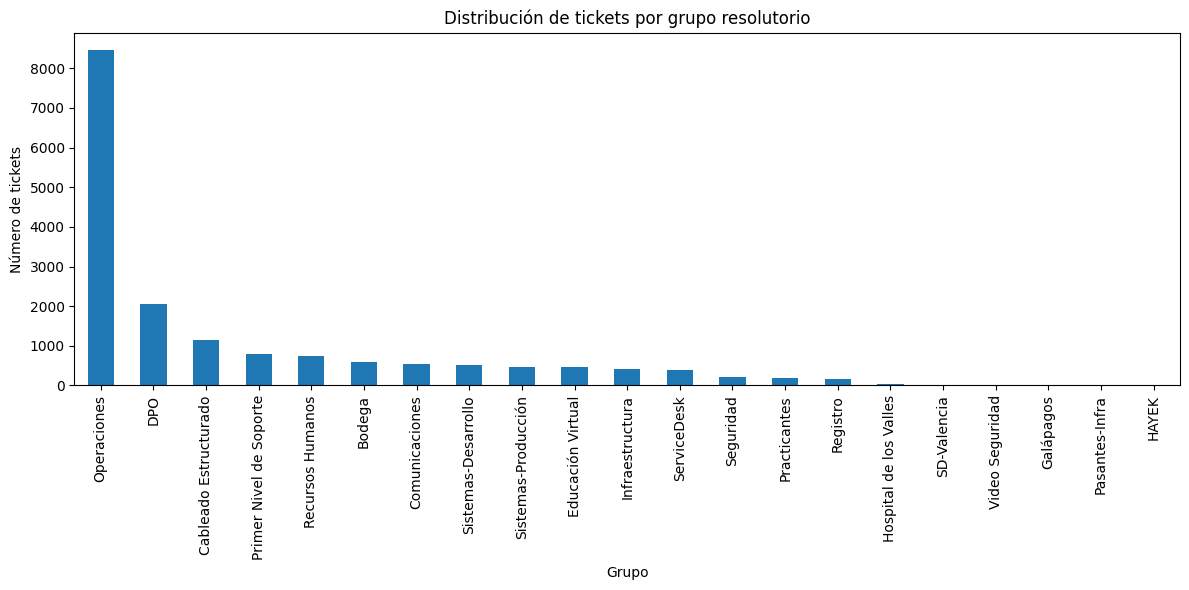

Número de grupos resolutorios: 21


In [25]:
# Distribución de la variable objetivo (Grupo)

grupo_counts = (
    df["Grupo"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
grupo_counts.plot(kind="bar")

plt.title("Distribución de tickets por grupo resolutorio")
plt.xlabel("Grupo")
plt.ylabel("Número de tickets")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

print(f"Número de grupos resolutorios: {grupo_counts.shape[0]}")

### Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar que el problema corresponde a una tarea de clasificación multiclase con **21 grupos resolutorios**. Asimismo, se verificó la existencia de valores nulos en la variable objetivo (*Grupo*), los cuales deberán tratarse durante la preparación de los datos.

Con base en este análisis, la siguiente etapa consistirá en construir el conjunto de datos que será utilizado para entrenar el modelo baseline.

## 4. Preparación de los datos

En esta sección se construirá el conjunto de datos que será utilizado para entrenar el modelo baseline. Para ello se aplicarán los filtros y transformaciones definidos durante el análisis exploratorio, garantizando que el modelo utilice únicamente información disponible al momento de la clasificación inicial del ticket.

In [26]:
# Construcción del dataset para Machine Learning

df_ml = df[
    (df["Estado"].isin(["Cerrada", "Rechazada"])) &
    (df["Grupo"].notna())
].copy()

print(f"Registros del dataset original : {len(df):,}")
print(f"Registros para Machine Learning: {len(df_ml):,}")
print(f"Registros descartados          : {len(df) - len(df_ml):,}")

Registros del dataset original : 24,392
Registros para Machine Learning: 16,404
Registros descartados          : 7,988


In [27]:
# Verificar valores nulos en las variables utilizadas por el modelo

print("Valores nulos en el dataset de Machine Learning:\n")

print(f"Título      : {df_ml['Título'].isnull().sum()}")
print(f"Descripción : {df_ml['Descripción'].isnull().sum()}")
print(f"Grupo       : {df_ml['Grupo'].isnull().sum()}")

Valores nulos en el dataset de Machine Learning:

Título      : 0
Descripción : 288
Grupo       : 0


In [28]:
# Eliminar registros sin descripción

df_ml = df_ml.dropna(subset=["Descripción"]).copy()

print(f"Registros disponibles para entrenamiento: {len(df_ml):,}")

Registros disponibles para entrenamiento: 16,116


### Construcción del texto de entrada

El modelo baseline utilizará como entrada una única representación textual construida a partir de la concatenación del **Título** y la **Descripción** del ticket.

Esta estrategia permite aprovechar tanto el resumen inicial del incidente como el detalle proporcionado por el usuario, generando una representación más completa para el proceso de clasificación.

In [29]:
# Construir el texto de entrada para el modelo

df_ml["Texto"] = (
    df_ml["Título"].str.strip() + " " +
    df_ml["Descripción"].str.strip()
)

# Eliminar espacios redundantes
df_ml["Texto"] = df_ml["Texto"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Ejemplos del texto de entrada:\n")

display(df_ml[["Título", "Descripción", "Texto"]].head())

Ejemplos del texto de entrada:



,Título,Descripción,Texto
0,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,"Buen día,\n\nEnvío la aprobación de Paolo Monc...",RV: Entrega de novedades SEGUNDO SEMESTRE 2022...
1,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,"\n\nBuen día,\n\nEnvío la aprobación de Paolo ...",RE: Entrega de novedades SEGUNDO SEMESTRE 2022...
2,FORMULARIO 107,Buenas tardes les pido de su gentileza me ayud...,FORMULARIO 107 Buenas tardes les pido de su ge...
3,Formulario 107,"Buenas tardes, espero que estén bien y que est...","Formulario 107 Buenas tardes, espero que estén..."
4,Problemas en el servidor,"Saludos,\n\nSoy Alvaro Villacis, profesor a ti...","Problemas en el servidor Saludos, Soy Alvaro V..."


### Limpieza del texto

Como parte del baseline, se aplicará un preprocesamiento mínimo al texto de entrada. Este proceso incluye la conversión a minúsculas, la eliminación de signos de puntuación y la normalización de espacios en blanco.

No se aplicarán técnicas adicionales como eliminación de stopwords, stemming o lematización, ya que estas formarán parte de los experimentos posteriores del proyecto.

In [30]:
# Función para la limpieza básica del texto

def limpiar_texto(texto):
    """
    Realiza la limpieza básica del texto para el modelo baseline.
    """

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar signos de puntuación
    texto = texto.translate(str.maketrans("", "", string.punctuation))

    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto)

    # Eliminar espacios al inicio y al final
    texto = texto.strip()

    return texto


# Aplicar limpieza al texto
df_ml["Texto_Limpio"] = df_ml["Texto"].apply(limpiar_texto)

print("Ejemplos del texto limpio:\n")

display(df_ml[["Texto", "Texto_Limpio"]].head())

Ejemplos del texto limpio:



,Texto,Texto_Limpio
0,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,rv entrega de novedades segundo semestre 20222...
1,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,re entrega de novedades segundo semestre 20222...
2,FORMULARIO 107 Buenas tardes les pido de su ge...,formulario 107 buenas tardes les pido de su ge...
3,"Formulario 107 Buenas tardes, espero que estén...",formulario 107 buenas tardes espero que estén ...
4,"Problemas en el servidor Saludos, Soy Alvaro V...",problemas en el servidor saludos soy alvaro vi...


In [31]:
# Definir variables de entrada (X) y variable objetivo (y)

X = df_ml["Texto_Limpio"]
y = df_ml["Grupo"]

print(f"Número de documentos: {len(X):,}")
print(f"Número de etiquetas : {len(y):,}")
print(f"Número de grupos    : {y.nunique()}")

Número de documentos: 16,116
Número de etiquetas : 16,116
Número de grupos    : 21


In [32]:
# División del dataset en entrenamiento (70%) y conjunto temporal (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Entrenamiento : {len(X_train):,} registros")
print(f"Temporal      : {len(X_temp):,} registros")

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [33]:
# Identificar grupos con muy pocos registros

grupo_frecuencia = y.value_counts()

display(grupo_frecuencia[grupo_frecuencia <= 5].sort_values())

,count
Grupo,
HAYEK,1
Pasantes-Infra,2


### Tratamiento de clases con muy baja representación

Durante la preparación del conjunto de datos se identificó un grupo resolutorio con un único registro histórico. Debido a que una clase con un solo ejemplo no permite realizar una partición estratificada ni proporciona información suficiente para el entrenamiento de un modelo supervisado, dicho registro fue excluido del dataset utilizado para el baseline.

Esta decisión busca garantizar la reproducibilidad del proceso de entrenamiento sin afectar de forma significativa el conjunto de datos disponible.

In [34]:
# Eliminar clases con un único registro

grupo_frecuencia = df_ml["Grupo"].value_counts()

grupos_validos = grupo_frecuencia[grupo_frecuencia >= 3].index

df_ml = df_ml[df_ml["Grupo"].isin(grupos_validos)].copy()

print(f"Registros disponibles para entrenamiento: {len(df_ml):,}")
print(f"Número de grupos resolutorios: {df_ml['Grupo'].nunique()}")

Registros disponibles para entrenamiento: 16,113
Número de grupos resolutorios: 19


In [35]:
# Variables de entrada (X) y variable objetivo (y)

X = df_ml["Texto_Limpio"]
y = df_ml["Grupo"]

print(f"Número de documentos: {len(X):,}")
print(f"Número de etiquetas : {len(y):,}")
print(f"Número de grupos    : {y.nunique()}")

Número de documentos: 16,113
Número de etiquetas : 16,113
Número de grupos    : 19


In [36]:
# División del conjunto de datos
# 70% Entrenamiento
# 15% Validación
# 15% Prueba

# Primera división (70% entrenamiento, 30% temporal)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Segunda división (15% validación, 15% prueba)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Distribución de los conjuntos:\n")

print(f"Entrenamiento : {len(X_train):,} registros")
print(f"Validación    : {len(X_val):,} registros")
print(f"Prueba        : {len(X_test):,} registros")

Distribución de los conjuntos:

Entrenamiento : 11,279 registros
Validación    : 2,417 registros
Prueba        : 2,417 registros


## 5. Vectorización mediante TF-IDF

Una vez preparado el conjunto de datos, se procede a dividirlo en los conjuntos de entrenamiento, validación y prueba, preservando la distribución de la variable objetivo mediante una partición estratificada.

Posteriormente, se aplica la técnica **TF-IDF (Term Frequency–Inverse Document Frequency)** para transformar el texto en una representación numérica que pueda ser utilizada por el modelo de Regresión Logística. El vocabulario del vectorizador se construye únicamente con el conjunto de entrenamiento para evitar *Data Leakage*, mientras que los conjuntos de validación y prueba son transformados utilizando ese mismo vocabulario.

In [37]:
# Crear el vectorizador TF-IDF

tfidf = TfidfVectorizer()

# Aprender el vocabulario únicamente del conjunto de entrenamiento
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformar validación y prueba utilizando el mismo vocabulario
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Vectorización completada.\n")

print(f"Tamaño matriz Train      : {X_train_tfidf.shape}")
print(f"Tamaño matriz Validación : {X_val_tfidf.shape}")
print(f"Tamaño matriz Prueba     : {X_test_tfidf.shape}")

print(f"\nNúmero de términos del vocabulario: {len(tfidf.vocabulary_):,}")

Vectorización completada.

Tamaño matriz Train      : (11279, 38108)
Tamaño matriz Validación : (2417, 38108)
Tamaño matriz Prueba     : (2417, 38108)

Número de términos del vocabulario: 38,108


## 6. Entrenamiento del modelo baseline

En esta sección se entrena el modelo baseline utilizando **Regresión Logística**, tomando como entrada la representación vectorial generada mediante TF-IDF.

Este modelo servirá como punto de referencia para comparar futuras mejoras del proyecto, tanto en el preprocesamiento del texto como en la incorporación de otros algoritmos de clasificación.

In [38]:
# Entrenamiento del modelo baseline

modelo = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

modelo.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 7. Evaluación del modelo baseline

En esta sección se evalúa el desempeño del modelo baseline utilizando el conjunto de prueba, el cual no participó en el entrenamiento del modelo.

La evaluación se realizará mediante métricas de clasificación y una matriz de confusión, permitiendo establecer una línea base objetiva para comparar futuras mejoras del proyecto.

In [39]:
# Generar predicciones sobre el conjunto de prueba

y_pred = modelo.predict(X_test_tfidf)

print("Predicciones generadas correctamente.")
print(f"Número de predicciones: {len(y_pred):,}")

Predicciones generadas correctamente.
Número de predicciones: 2,417


In [40]:
# Evaluación del modelo baseline

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.7894

Classification Report:

                         precision    recall  f1-score   support

                 Bodega       0.97      0.47      0.63        68
  Cableado Estructurado       0.85      0.56      0.68       158
         Comunicaciones       0.91      0.41      0.57        73
                    DPO       1.00      0.98      0.99       288
      Educación Virtual       0.68      0.63      0.66        68
              Galápagos       0.00      0.00      0.00         1
 Hospital de los Valles       0.00      0.00      0.00         6
        Infraestructura       0.57      0.07      0.12        58
            Operaciones       0.75      0.97      0.84      1194
           Practicantes       0.00      0.00      0.00        26
Primer Nivel de Soporte       0.48      0.44      0.46       109
       Recursos Humanos       0.92      0.75      0.82       110
               Registro       0.67      0.24      0.35        25
            SD-Valencia       0.00      0.00   

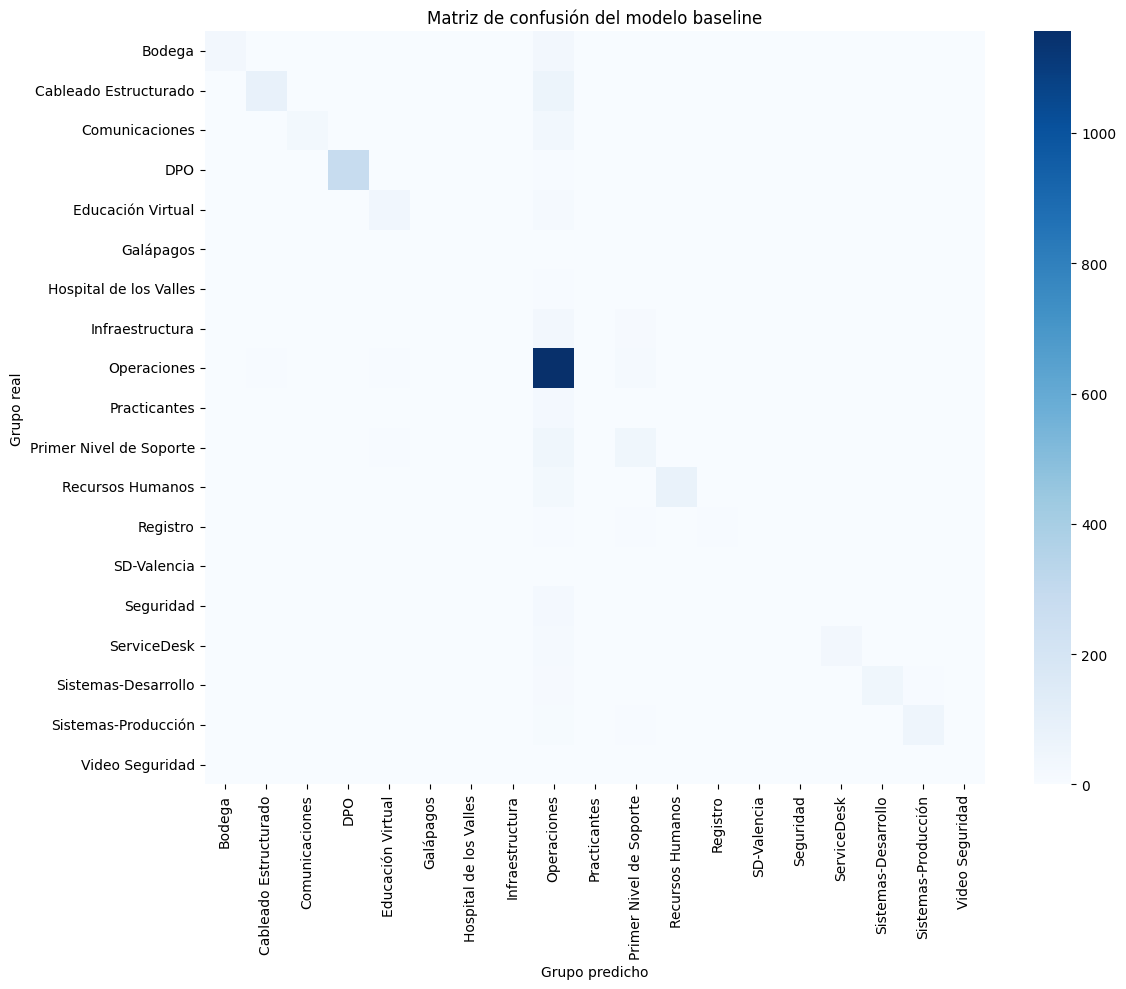

In [41]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_,
    cbar=True
)

plt.title("Matriz de confusión del modelo baseline")
plt.xlabel("Grupo predicho")
plt.ylabel("Grupo real")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Conclusiones

El modelo baseline obtuvo un **Accuracy de 78,94 %**, demostrando que la combinación de **TF-IDF** y **Regresión Logística** constituye una línea base adecuada para la clasificación inicial de tickets de la mesa de ayuda.

Los resultados evidencian un mejor desempeño en los grupos con mayor representación en el conjunto de datos y un rendimiento limitado en las clases con pocos ejemplos, lo que justifica la realización de experimentos posteriores orientados a optimizar el preprocesamiento del texto y evaluar modelos alternativos.